<a href="https://colab.research.google.com/github/Anusree-ss780/ML-LAB/blob/main/exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import libraries


In [8]:
import numpy as np

In [9]:
import matplotlib.pyplot as plt

In [10]:
from sklearn.datasets import fetch_california_housing

In [11]:
from sklearn.metrics import mean_squared_error,r2_score

#load california housing dataset

In [12]:
housing=fetch_california_housing(as_frame=True)

In [13]:
df=housing.frame

#select one feature(average rooms) and target (median house value)

In [14]:
x=df['AveRooms'].values

In [15]:
y=df['MedHouseVal'].values.reshape(-1,1)

#add bias term

In [16]:
x_b=np.c_[np.ones((len(x),1)),x]

#METHOD 1:NORMAL EQUATION

In [17]:
theta_normal=np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y

In [18]:
y_pred_normal=x_b @ theta_normal

In [19]:
print("-----Normal Equation-----")
print("Intercept:",theta_normal[0][0])
print("Slope :",theta_normal[1][0])
print("MSE:",mean_squared_error(y,y_pred_normal))
print("R2 Score:",r2_score(y,y_pred_normal))

-----Normal Equation-----
Intercept: 1.6838115086404832
Slope : 0.0708687932804052
MSE: 1.3008070902505424
R2 Score: 0.023088282755354017


#METHOD 2 :Gradient

In [26]:
def compute_cost(x,y,theta):
  m=len(y)
  predictions=x@theta
  cost=(1/(2*m)) * np.sum((predictions-y)**2)
  return cost

In [27]:
 def gradient_descent(x,y,theta,learning_rate,iterations):
    m=len(y)
    cost_history=[]
    for i in range(iterations):

       grandients=(1/m) * (x.T @ (x@theta-y))
       theta=theta-learning_rate*grandients
       cost_history.append(compute_cost(x,y,theta))
    return theta,cost_history

In [28]:
theta=np.zeros((2,1))
learning_rate=0.001
iterations=1000
theta_gradient,cost_history=gradient_descent(x_b,y,theta,learning_rate,iterations)
y_pred_gradient=x_b@theta_gradient

In [29]:
print("-----Gradient Descent-----")
print("Intercept:",theta_gradient[0][0])
print("Slope :",theta_gradient[1][0])
print("MSE:",mean_squared_error(y,y_pred_gradient))
print("R2 Score:",r2_score(y,y_pred_gradient))

-----Gradient Descent-----
Intercept: 0.3020999765307546
Slope : 0.2826073529823789
MSE: 1.6291507228490774
R2 Score: -0.22349919695034104


#VISUALIZATION

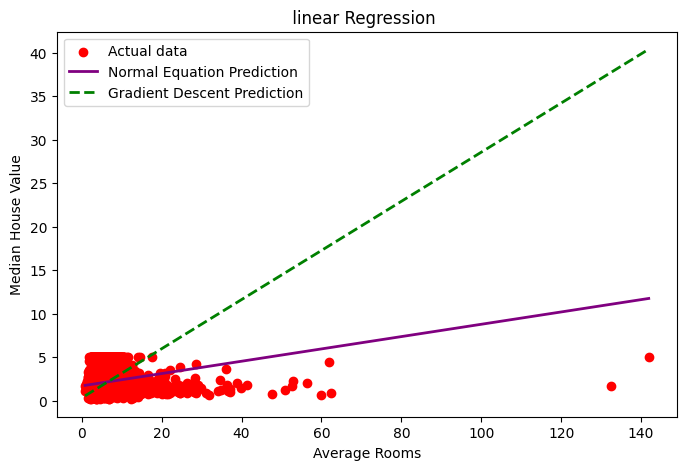

In [30]:
import numpy as np
sort_index= np.argsort(x.flatten())
plt.figure(figsize=(8,5))
plt.scatter(x[sort_index],y[sort_index],color='red', label='Actual data')
plt.plot(x[sort_index],y_pred_normal[sort_index],color='purple',linewidth=2,label='Normal Equation Prediction')
plt.plot(x[sort_index],y_pred_gradient[sort_index],color='green',linestyle='dashed',linewidth=2,label='Gradient Descent Prediction')

plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.title(" linear Regression  ")
plt.legend()
plt.show()

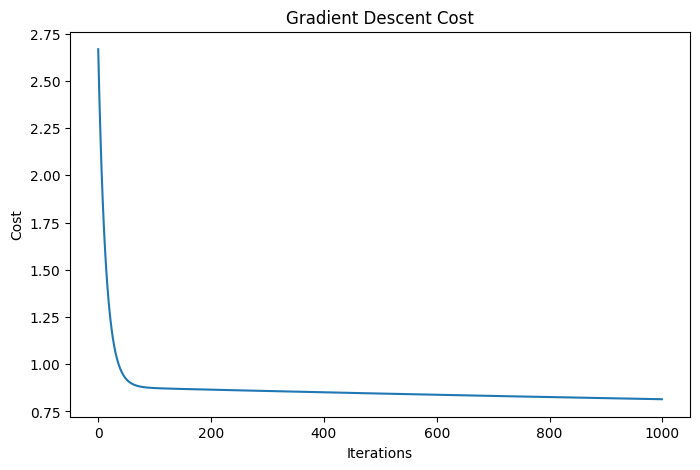

In [32]:
 plt.figure(figsize=(8,5))
 plt.plot(cost_history)
 plt.xlabel("Iterations")
 plt.ylabel("Cost")
 plt.title("Gradient Descent Cost")
 plt.show()